Combined RL Training for Industrial Inventory Environment
==========================================================
This script implements and compares 5 RL algorithms:
1. A2C
2. PPO  
3. DQN
4. Double DQN
5. REINFORCE with Baseline

All algorithms use the same environment, evaluation protocol, and hyperparameter tuning via Optuna.

In [1]:
from typing import Any, Callable, Literal
from functools import partial
from collections import deque
import os
import json
import warnings
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
import gymnasium as gym
from gymnasium.spaces import Discrete
import optuna
from stable_baselines3 import A2C, PPO, DQN
from stable_baselines3.common.base_class import BaseAlgorithm
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor
from stable_baselines3.common.evaluation import evaluate_policy

from industrial_inventory_env import IndustrialInventoryEnv, generate_student_config, public_config_summary

warnings.filterwarnings('ignore')

SEED = 2026
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
ROLL_NUMBER = "DA25M622"
student_config = generate_student_config(ROLL_NUMBER)
config_summary = public_config_summary(student_config)

print("Assigned configuration generated successfully.")
for key, value in config_summary.items():
    print(f"{key}: {value}")

Assigned configuration generated successfully.
project_version: IITM-6002W-RL-Inventory-2026-v1
roll_number: DA25M622
variant_id: V022
config_fingerprint: 7d77fc79debf206a
demand_multiplier_profile: [1.0, 1.1, 0.9]
initial_inventory_profile: [110, 100, 90]
lead_time_delay_profile: [0.1, 0.0, 0.05]


In [ ]:
def make_env_fn():
    """Create a single environment instance."""
    return IndustrialInventoryEnv(
        student_config=student_config,
        scenario_mode="random",
        domain_randomization=True,
    )


def make_vec_env_fn(seed: int):
    """Create vectorized environment for SB3 algorithms (so RL policy can train in parallel on 4 instances of the environment)."""
    vec_env = make_vec_env(make_env_fn, n_envs=4, seed=seed)
    return VecMonitor(vec_env)


def evaluate_cost_sb3(model: BaseAlgorithm) -> tuple[float, float]:
    """Evaluate SB3 model on 20 episodes and return episodic cost statistics: tuple (mean_cost, std_cost)."""
    env = make_env_fn()
    _observation, _info = env.reset(seed=2026)
    mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=20, deterministic=True)  # evaluate_policy returns mean reward (negative cost/100)
    env.close()
    
    # Convert reward to cost: reward = -cost/100
    mean_cost = -mean_reward * 100.0
    std_cost = std_reward * 100.0
    return mean_cost, std_cost


def evaluate_cost_custom(model: nn.Module) -> tuple[float, float]:
    """Evaluate custom policy (for REINFORCE) by running 20 episodes. Returns episodic cost statistics: tuple (mean_cost, std_cost)."""
    costs: list[float] = []
    for ep in range(20):
        env = make_env_fn()
        obs, info = env.reset(seed = SEED + ep)
        while True:
            obs_tensor_dict = obs_to_tensor(obs)
            action, _ = get_action_and_log_prob(model, obs_tensor_dict, deterministic=True)
            obs, _reward, terminated, truncated, info = env.step(action)
            if terminated or truncated:
                costs.append(info["costs"]["episode_total"])
                break
        env.close()
    return float(np.mean(costs)), float(np.std(costs))


# ============================================================================
# Action Wrapper for DQN/Double DQN (Flattens MultiDiscrete to Discrete)
# ============================================================================

class FlattenMultiDiscreteActionWrapper(gym.ActionWrapper):
    """Maps MultiDiscrete([11, 11, 11]) to Discrete(1331)."""
    def __init__(self, env: gym.Env):
        super().__init__(env)
        self.nvec = env.action_space.nvec
        self.action_space = Discrete(int(np.prod(self.nvec)))

    def action(self, action: int) -> np.ndarray:
        multi_action = np.unravel_index(action, self.nvec)
        return np.array(multi_action, dtype=self.env.action_space.dtype)


def make_dqn_env_fn():
    """Create environment with flattened action space for DQN."""
    return FlattenMultiDiscreteActionWrapper(make_env_fn())


# ============================================================================
# REINFORCE with Baseline
# ============================================================================

def obs_to_tensor(obs: dict[str, np.ndarray]) -> dict[str, torch.Tensor]:
    """Convert dictionary observation's numpy arrays to tensors."""
    return {
        'inventory': torch.as_tensor(obs['inventory'], dtype=torch.float32, device=DEVICE),
        'arrival_pipeline': torch.as_tensor(obs['arrival_pipeline'], dtype=torch.float32, device=DEVICE),
        'demand_history': torch.as_tensor(obs['demand_history'], dtype=torch.float32, device=DEVICE),
        'day': torch.as_tensor(obs['day'], dtype=torch.float32, device=DEVICE),
        'capacity_utilisation': torch.as_tensor(obs['capacity_utilisation'], dtype=torch.float32, device=DEVICE)
    }


class PolicyNetwork(nn.Module):
    """Policy network for industrial inventory environment."""
    def __init__(self, hidden_dims=[256, 128], num_actions=11):
        super().__init__()
        
        total_state_dim = 3 + 12 + 21 + 1 + 1  # 38 total
        
        layers = []
        prev_dim = total_state_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU())
            prev_dim = h_dim
        
        self.shared = nn.Sequential(*layers)
        self.action_head = nn.Linear(prev_dim, 3 * num_actions)
        self.num_actions = num_actions
        
    def forward(self, obs_dict):
        if obs_dict['inventory'].dim() == 1:
            batch_size = 1
            inventory = obs_dict['inventory'].float().unsqueeze(0)
            arrival_pipeline = obs_dict['arrival_pipeline'].float().flatten().unsqueeze(0)
            demand_history = obs_dict['demand_history'].float().flatten().unsqueeze(0)
            day = obs_dict['day'].float().unsqueeze(0)
            capacity_utilisation = obs_dict['capacity_utilisation'].float().unsqueeze(0)
        else:
            batch_size = obs_dict['inventory'].shape[0]
            inventory = obs_dict['inventory'].float()
            arrival_pipeline = obs_dict['arrival_pipeline'].float().view(batch_size, -1)
            demand_history = obs_dict['demand_history'].float().view(batch_size, -1)
            day = obs_dict['day'].float().view(batch_size, -1)
            capacity_utilisation = obs_dict['capacity_utilisation'].float().view(batch_size, -1)
        
        features = torch.cat([inventory, arrival_pipeline, demand_history, day, capacity_utilisation], dim=1)
        x = self.shared(features)
        logits = self.action_head(x)
        logits = logits.view(batch_size, 3, self.num_actions)
        
        if batch_size == 1:
            logits = logits.squeeze(0)
        return logits


class ValueNetwork(nn.Module):
    """Value network for baseline."""
    def __init__(self, hidden_dims=[256, 128]):
        super().__init__()
        
        total_state_dim = 3 + 12 + 21 + 1 + 1
        
        layers = []
        prev_dim = total_state_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU())
            prev_dim = h_dim
        
        self.shared = nn.Sequential(*layers)
        self.value_head = nn.Linear(prev_dim, 1)
        
    def forward(self, obs_dict):
        if obs_dict['inventory'].dim() == 1:
            batch_size = 1
            inventory = obs_dict['inventory'].float().unsqueeze(0)
            arrival_pipeline = obs_dict['arrival_pipeline'].float().flatten().unsqueeze(0)
            demand_history = obs_dict['demand_history'].float().flatten().unsqueeze(0)
            day = obs_dict['day'].float().unsqueeze(0)
            capacity_utilisation = obs_dict['capacity_utilisation'].float().unsqueeze(0)
        else:
            batch_size = obs_dict['inventory'].shape[0]
            inventory = obs_dict['inventory'].float()
            arrival_pipeline = obs_dict['arrival_pipeline'].float().view(batch_size, -1)
            demand_history = obs_dict['demand_history'].float().view(batch_size, -1)
            day = obs_dict['day'].float().view(batch_size, -1)
            capacity_utilisation = obs_dict['capacity_utilisation'].float().view(batch_size, -1)
        
        features = torch.cat([inventory, arrival_pipeline, demand_history, day, capacity_utilisation], dim=1)
        x = self.shared(features)
        value = self.value_head(x)
        
        if batch_size == 1:
            value = value.squeeze(0)
        else:
            value = value.squeeze(-1)
        return value

def discounted_returns(rewards: list[float], gamma: float) -> np.ndarray:
    """Calculate discounted returns."""
    returns = np.zeros(len(rewards), dtype=np.float32)
    G = 0.0
    for t in range(len(rewards) - 1, -1, -1):
        G = rewards[t] + gamma * G
        returns[t] = G
    return returns


def get_action_and_log_prob(model: nn.Module, obs_tensor: dict[str, torch.Tensor], deterministic: bool = False) -> tuple[np.ndarray, torch.Tensor]:
    """Get action and log probability from RL model."""
    logits: torch.Tensor = model(obs_tensor)
    
    actions = []
    log_probs: list[float] = []
    for product_idx in range(3):
        product_logits = logits[product_idx]
        if deterministic:
            action = torch.argmax(product_logits)
            log_prob = F.log_softmax(product_logits, dim=-1)[action]
        else:
            dist = Categorical(logits=product_logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)
        actions.append(action.item())
        log_probs.append(log_prob)
    
    return np.array(actions, dtype=np.int32), torch.stack(log_probs).sum()


def generate_episode(env: gym.Env, model: nn.Module, max_steps: int, seed: int) -> dict[str, Any]:
    """Generate one complete episode."""
    obs_numpy_dict, info = env.reset(seed=seed)
    
    states: list[dict[str, torch.Tensor]] = []
    actions_list: list[torch.Tensor] = []
    rewards: list[float] = []
    log_probs: list[torch.Tensor] = []
    
    for _step in range(max_steps):
        obs_tensor_dict = obs_to_tensor(obs_numpy_dict)
        action, log_prob = get_action_and_log_prob(model, obs_tensor_dict, deterministic=False)
        next_obs, reward, terminated, truncated, info = env.step(action)
        
        states.append(obs_tensor_dict)
        actions_list.append(torch.tensor(action, dtype=torch.float32, device=DEVICE))
        rewards.append(float(reward))
        log_probs.append(log_prob)
        obs_numpy_dict = next_obs
        
        if terminated or truncated:
            return {
                "states": states,
                "actions": torch.stack(actions_list),
                "rewards": rewards,
                "log_probs": torch.stack(log_probs),
                "success": bool(terminated),
                "length": len(rewards),
                "total_cost": info['costs']['episode_total']
            }
    
    return {
        "states": states,
        "actions": torch.stack(actions_list),
        "rewards": rewards,
        "log_probs": torch.stack(log_probs),
        "success": False,
        "length": len(rewards),
        "total_cost": info['costs']['episode_total']
    }


def batch_states(states) -> dict[str, torch.Tensor]:
    """Batch a list of dictionary observations."""
    batched = {}
    for key in states[0].keys():
        batched[key] = torch.stack([s[key] for s in states])
    return batched


def train_reinforce(
    num_episodes: int,
    gamma: float,
    actor_lr: float,
    critic_lr: float,
    hidden_dims: list[int],
    use_baseline: bool,
    advantage_norm: bool,
    entropy_coef: bool,
    grad_clip: bool,
    eval_interval: int,
    n_eval_episodes: int,
    verbose: bool
) -> tuple[nn.Module, nn.Module, dict[str, list]]:
    """Train REINFORCE with baseline. Returns (policy_model, value_model, history_dict)."""
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    
    model = PolicyNetwork(hidden_dims).to(DEVICE)
    policy_optimizer = torch.optim.Adam(model.parameters(), lr=actor_lr)
    # value_net for baseline
    value_net = ValueNetwork(hidden_dims).to(DEVICE)
    value_optimizer = torch.optim.Adam(value_net.parameters(), lr=critic_lr)
    
    history = {
        "episode_costs": [],
        "episode_lengths": [],
        "eval_costs": [],
        "eval_lengths": [],
        "actor_losses": [],
        "critic_losses": [],
        "entropy": []
    }
    
    best_eval_cost = float('inf')
    best_policy_state = None
    
    for episode_idx in range(num_episodes):
        episode_seed = SEED + episode_idx
        episode = generate_episode(make_env_fn(), model, max_steps=1000, seed=episode_seed)
        
        batched_states = batch_states(episode["states"])
        log_probs = episode["log_probs"]
        
        # Calculate returns
        returns = torch.tensor(
            discounted_returns(episode["rewards"], gamma),
            dtype=torch.float32,
            device=DEVICE
        )
        
        # Compute advantages
        if use_baseline:
            with torch.no_grad():
                values = value_net(batched_states)
            advantages = returns - values
            if advantage_norm and advantages.std() > 1e-8:
                advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
            elif advantage_norm:
                advantages = advantages - advantages.mean()
        else:
            advantages = returns
        
        # Actor loss with entropy bonus
        gamma_t = gamma ** torch.arange(len(episode["rewards"]), dtype=torch.float32, device=DEVICE)
        actor_loss = -(gamma_t * advantages * log_probs).mean()
        
        # Entropy bonus
        logits = model(batched_states)
        entropy = 0
        for p in range(3):
            dist = Categorical(logits=logits[:, p, :])
            entropy += dist.entropy().mean()
        entropy_loss = -entropy_coef * entropy
        
        total_actor_loss = actor_loss + entropy_loss
        
        policy_optimizer.zero_grad()
        total_actor_loss.backward()
        if grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        policy_optimizer.step()
        
        critic_loss = torch.tensor(0.0, device=DEVICE)
        if use_baseline:
            values = value_net(batched_states)
            critic_loss = F.mse_loss(values, returns)
            value_optimizer.zero_grad()
            critic_loss.backward()
            if grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(value_net.parameters(), max_norm=grad_clip)
            value_optimizer.step()
        
        history["episode_costs"].append(episode["total_cost"])
        history["episode_lengths"].append(episode["length"])
        history["actor_losses"].append(actor_loss.item())
        history["critic_losses"].append(critic_loss.item() if use_baseline else 0)
        history["entropy"].append(entropy.item())
        
        # Evaluation
        if (episode_idx + 1) % eval_interval == 0:
            eval_costs, eval_lengths = evaluate_custom_policy(
                model, n_episodes=n_eval_episodes, seed=seed + episode_idx
            )
            mean_cost = np.mean(eval_costs)
            history["eval_costs"].append(mean_cost)
            history["eval_lengths"].append(np.mean(eval_lengths))
            
            if mean_cost < best_eval_cost:
                best_eval_cost = mean_cost
                best_policy_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

            if verbose:
                print(
                    f"Episode {episode_idx + 1:4d} | "
                    f"Cost: {episode['total_cost']:.1f} | "
                    f"Len: {episode['length']:.0f} | "
                    f"Eval Cost: {mean_cost:.1f} ± {np.std(eval_costs):.1f} | "
                    f"Entropy: {entropy.item():.4f}"
                )
    
    if best_policy_state is not None:
        model.load_state_dict(best_policy_state)
    
    return model, value_net, history

def evaluate_custom_policy(model: nn.Module) -> tuple[list[float], list[int]]:
    """Evaluate a trained policy."""
    model.eval()
    
    costs = []
    lengths = []
    
    with torch.no_grad():
        for ep in range(20):
            env = make_env_fn()
            obs, info = env.reset(seed=SEED + ep)
            
            total_cost = 0
            episode_len = 0
            
            while True:
                obs_tensor = obs_to_tensor(obs)
                action, _ = get_action_and_log_prob(model, obs_tensor, deterministic=True)
                obs, _reward, terminated, truncated, info = env.step(action)
                episode_len += 1
                
                if terminated or truncated:
                    total_cost = info['costs']['episode_total']
                    break
            
            costs.append(total_cost)
            lengths.append(episode_len)
            env.close()
    
    model.train()
    return costs, lengths


# ============================================================================
# Double DQN (Subclass of DQN with custom train)
# ============================================================================

class DoubleDQN(DQN):
    """Double DQN implementation by overriding the train method of Stable-Baseline3's DQN class.
    
    Adapted training code from source code of DQN class (only a slight 2-lines change needed to be done).
    """
    def train(self, gradient_steps: int, batch_size: int = 100) -> None:
        self.policy.set_training_mode(True)
        self._update_learning_rate(self.policy.optimizer)

        losses: list[float] = []
        for _ in range(gradient_steps):
            replay_data = self.replay_buffer.sample(batch_size, env=self._vec_normalize_env)
            discounts = replay_data.discounts if replay_data.discounts is not None else self.gamma

            with torch.no_grad():

                next_actions = self.q_net(replay_data.next_observations).argmax(dim=1, keepdim=True)
                next_q_values = self.q_net_target(replay_data.next_observations).gather(1, next_actions)
                next_q_values = next_q_values.reshape(-1, 1)
                target_q_values = replay_data.rewards + (1 - replay_data.dones) * discounts * next_q_values

            current_q_values = self.q_net(replay_data.observations)
            current_q_values = torch.gather(current_q_values, dim=1, index=replay_data.actions.long())

            loss = F.smooth_l1_loss(current_q_values, target_q_values)
            losses.append(loss.item())

            self.policy.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.policy.parameters(), self.max_grad_norm)
            self.policy.optimizer.step()

        self._n_updates += gradient_steps
        self.logger.record("train/n_updates", self._n_updates, exclude="tensorboard")
        self.logger.record("train/loss", np.mean(losses))


# ============================================================================
# Optuna Hyperparameter Tuning
# ============================================================================

def objective_a2c(trial: optuna.Trial) -> float:
    """Objective function for A2C hyperparameter tuning."""
    params = {
        "gamma": trial.suggest_categorical("gamma", [0.98, 0.99, 0.995]),
        "gae_lambda": trial.suggest_categorical("gae_lambda", [0.90, 0.95, 0.98]),
        "learning_rate": trial.suggest_float("learning_rate", 3e-5, 8e-4, log=True),
        "ent_coef": trial.suggest_float("ent_coef", 1e-5, 1e-2, log=True),
        "vf_coef": trial.suggest_float("vf_coef", 0.25, 0.75),
        "max_grad_norm": trial.suggest_float("max_grad_norm", 0.3, 0.7),
        "n_steps": trial.suggest_categorical("n_steps", [5, 10, 20, 32, 64, 128, 256]),
    }
    
    # Network architecture
    net_arch = trial.suggest_categorical("net_arch", ["small", "medium"])
    layers = [128, 128] if net_arch == "small" else [256, 256]
    policy_kwargs = dict(
        net_arch=dict(pi=layers, vf=layers),
        activation_fn=nn.ReLU
    )
    
    vec_env = make_vec_env_fn(SEED)
    
    model = A2C(
        policy="MultiInputPolicy",
        env=vec_env,
        verbose=0,
        seed=2026,
        policy_kwargs=policy_kwargs,
        **params
    )
    
    try:
        model.learn(total_timesteps=60_000)
        mean_cost, _ = evaluate_cost_sb3(model)
    except Exception as e:
        vec_env.close()
        raise e
        
    vec_env.close()
    return mean_cost


def objective_ppo(trial: optuna.Trial) -> float:
    """Objective function for PPO hyperparameter tuning."""
    # Ensure batch_size evenly divides total buffer size (n_steps * n_envs)
    n_envs = 4
    n_steps = trial.suggest_categorical("n_steps", [64, 128, 256, 512])
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    total_buffer = n_steps * n_envs
    if total_buffer % batch_size != 0:
        batch_size = n_steps  # Safe fallback
    
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 7.5e-4, log=True),
        "n_steps": n_steps,
        "batch_size": batch_size,
        "n_epochs": trial.suggest_categorical("n_epochs", [5, 10, 15]),
        "gamma": trial.suggest_categorical("gamma", [0.95, 0.98, 0.99, 0.995]),
        "gae_lambda": trial.suggest_categorical("gae_lambda", [0.85, 0.90, 0.95, 0.98]),
        "clip_range": trial.suggest_categorical("clip_range", [0.1, 0.2, 0.3]),
        "ent_coef": trial.suggest_float("ent_coef", 0.001, 0.02, log=True),
        "vf_coef": trial.suggest_float("vf_coef", 0.25, 0.75),
        "max_grad_norm": trial.suggest_categorical("max_grad_norm", [0.5, 0.7, 1.0]),
    }
    
    net_arch = trial.suggest_categorical("net_arch", ["small", "medium"])
    if net_arch == "small":
        policy_kwargs = dict(net_arch=dict(pi=[128, 128], vf=[128, 128]))
    else:         # "medium"
        policy_kwargs = dict(net_arch=dict(pi=[256, 256], vf=[256, 256]))
    
    vec_env = make_vec_env_fn(SEED)
    eval_env = make_vec_env_fn(42)
    
    model = PPO(
        policy="MultiInputPolicy",
        env=vec_env,
        verbose=0,
        seed=2026,
        policy_kwargs=policy_kwargs,
        **params
    )
    
    try:
        model.learn(total_timesteps=80_000)
        mean_reward, _ = evaluate_policy(model, eval_env, n_eval_episodes=15, deterministic=True)
        mean_cost = -mean_reward * 100.0
    except Exception as e:
        vec_env.close()
        eval_env.close()
        raise e
        
    vec_env.close()
    eval_env.close()
    return mean_cost


def objective_dqn(trial: optuna.Trial) -> float:
    """Objective function for DQN hyperparameter tuning."""
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 3e-4, 1.5e-3, log=True),
        "gamma": trial.suggest_categorical("gamma", [0.95, 0.98, 0.99]),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128]),
        "target_update_interval": trial.suggest_categorical("target_update_interval", [250, 500, 1000]),
        "train_freq": trial.suggest_categorical("train_freq", [4, 8]),
        "gradient_steps": trial.suggest_categorical("gradient_steps", [4, 8]),
        "exploration_fraction": trial.suggest_categorical("exploration_fraction", [0.3, 0.5]),
        "exploration_final_eps": trial.suggest_categorical("exploration_final_eps", [0.02, 0.05]),
    }
    
    net_arch = trial.suggest_categorical("net_arch", ["small", "medium"])
    if net_arch == "small":
        policy_kwargs = dict(net_arch=[256, 256])
    else:
        policy_kwargs = dict(net_arch=[512, 256])
    
    vec_env = make_vec_env_fn(SEED)
    eval_env = make_vec_env_fn(seed=42)
    
    model = DQN(
        policy="MultiInputPolicy",
        env=vec_env,
        buffer_size=100000,
        learning_starts=1000,
        verbose=0,
        seed=2026,
        policy_kwargs=policy_kwargs,
        **params
    )
    
    try:
        model.learn(total_timesteps=40_000)
        mean_reward, _ = evaluate_policy(model, eval_env, n_eval_episodes=20, deterministic=True)
        mean_cost = -mean_reward * 100.0
    except Exception as e:
        vec_env.close()
        eval_env.close()
        raise e
        
    vec_env.close()
    eval_env.close()
    return mean_cost


def objective_double_dqn(trial: optuna.Trial) -> float:
    """Objective function for Double DQN hyperparameter tuning."""
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 5e-5, 5e-4, log=True),
        "gamma": trial.suggest_categorical("gamma", [0.95, 0.98, 0.99]),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256]),
        "buffer_size": trial.suggest_categorical("buffer_size", [50000, 100000]),
        "learning_starts": trial.suggest_categorical("learning_starts", [500, 1000, 2000]),
        "train_freq": trial.suggest_categorical("train_freq", [1, 4]),
        "gradient_steps": trial.suggest_categorical("gradient_steps", [1, 2]),
        "target_update_interval": trial.suggest_categorical("target_update_interval", [500, 1000, 2000]),
        "exploration_fraction": trial.suggest_categorical("exploration_fraction", [0.25, 0.40, 0.50]),
        "exploration_final_eps": trial.suggest_categorical("exploration_final_eps", [0.02, 0.05, 0.10]),
    }
    
    net_arch = trial.suggest_categorical("net_arch", ["small", "medium"])
    if net_arch == "small":
        policy_kwargs = dict(net_arch=[128, 128])
    else:        # "medium"
        policy_kwargs = dict(net_arch=[256, 128])
    
    vec_env = make_vec_env_fn(SEED)
    eval_env = make_vec_env_fn(seed=42)
    
    model = DoubleDQN(
        policy="MultiInputPolicy",
        env=vec_env,
        verbose=0,
        seed=2026,
        policy_kwargs=policy_kwargs,
        **params
    )
    
    try:
        model.learn(total_timesteps=30_000)
        mean_reward, _ = evaluate_policy(model, eval_env, n_eval_episodes=20, deterministic=True)
        mean_cost = -mean_reward * 100.0
    except Exception as e:
        vec_env.close()
        eval_env.close()
        raise e
        
    vec_env.close()
    eval_env.close()
    return mean_cost


def objective_reinforce(trial: optuna.Trial) -> float:
    """Objective function for REINFORCE hyperparameter tuning."""
    params = {
        "actor_lr": trial.suggest_float("actor_lr", 1e-4, 1e-3, log=True),
        "critic_lr": trial.suggest_float("critic_lr", 3e-4, 2e-3, log=True),
        "gamma": trial.suggest_categorical("gamma", [0.95, 0.98, 0.99, 0.995]),
        "entropy_coef": trial.suggest_float("entropy_coef", 0.001, 0.02, log=True),
        "advantage_norm": trial.suggest_categorical("advantage_norm", [True, False]),
    }
    
    hidden_dims = trial.suggest_categorical("hidden_dims", ["small", "medium", "large"])
    if hidden_dims == "small":
        hidden_dims_list = [128, 64]
    elif hidden_dims == "medium":
        hidden_dims_list = [256, 128]
    else:         # "large"
        hidden_dims_list = [256, 128, 64]
    
    try:
        policy_model, value_model, history = train_reinforce(
            num_episodes=80,
            gamma=params["gamma"],
            actor_lr=params["actor_lr"],
            critic_lr=params["critic_lr"],
            hidden_dims=hidden_dims_list,
            use_baseline=True,
            advantage_norm=params["advantage_norm"],
            entropy_coef=params["entropy_coef"],
            grad_clip=1.0,
            eval_interval=20,
            n_eval_episodes=20,
            verbose=False
        )
        
        mean_cost, _ = evaluate_custom_policy(policy_model)
        return mean_cost
    except Exception as e:
        print('ERROR in objective_reinforce:', e)
        return 1e9  # Return high cost for failed trials


def run_optuna_tuning(objective_func: Callable[[optuna.Trial], float]) -> optuna.Study:
    """Run Optuna optimization for a given objective."""
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
    )
    
    study.optimize(objective_func, n_trials=15, timeout=1800)
    
    print(f"Best trial value: {study.best_trial.value:.2f}")
    print("Best params:")
    for key, value in study.best_trial.params.items():
        print(f"  {key}: {value}")
    
    return study


# ============================================================================
# Final Re-Training and Evaluation (after finding out best params using Optuna)
# ============================================================================

def train_and_evaluate_a2c(best_params: dict[str, Any]) -> tuple[BaseAlgorithm, float, float]:
    """Train A2C with best params and evaluate. Returns tuple (model, mean_cost, std_cost)."""
    print("\n" + "=" * 60)
    print("Training A2C with Best Hyperparameters")
    print("=" * 60)
    
    # Prepare policy kwargs
    # "net_arch" is deleted from best_params as it's NOT an argument of A2C(), so prevent it from reaching A2C() constructor
    net_arch: Literal["small", "medium"] = best_params.pop("net_arch")          
    layers = [128, 128] if net_arch == "small" else [256, 256]
    policy_kwargs = dict(
        net_arch=dict(pi=layers, vf=layers),
        activation_fn=nn.ReLU
    )
    
    vec_env = make_vec_env_fn(SEED)
    
    model = A2C(
        policy="MultiInputPolicy",
        env=vec_env,
        verbose=1,
        seed=2026,
        policy_kwargs=policy_kwargs,
        **best_params
    )
    
    model.learn(total_timesteps=200_000)
    vec_env.close()
    
    # Evaluate
    mean_cost, std_cost = evaluate_cost_sb3(model, n_eval_episodes=20, eval_seed=2026)
    print(f"A2C Final Cost: {mean_cost:.2f} ± {std_cost:.2f}")
    
    # Save model
    model.save("best_a2c_model")
    print("A2C model saved to best_a2c_model.zip")
    
    return model, mean_cost, std_cost

def train_and_evaluate_ppo(best_params: dict[str, Any]) -> tuple[BaseAlgorithm, float, float]:
    """Train PPO with best params and evaluate. Returns tuple (model, mean_cost, std_cost)."""
    print("\n" + "=" * 60)
    print("Training PPO with Best Hyperparameters")
    print("=" * 60)
    
    # Ensure batch_size divides n_steps * n_envs
    n_envs = 8
    total_buffer = best_params["n_steps"] * n_envs
    if total_buffer % best_params["batch_size"] != 0:
        best_params["batch_size"] = best_params["n_steps"]
    
    # Prepare policy kwargs
    net_arch: Literal["small", "medium"] = best_params.pop("net_arch")
    if net_arch == "small":
        policy_kwargs = dict(net_arch=dict(pi=[128, 128], vf=[128, 128]))
    else:  # "medium"
        policy_kwargs = dict(net_arch=dict(pi=[256, 256], vf=[256, 256]))
    
    vec_env = make_vec_env_fn(SEED)
    
    model = PPO(
        policy="MultiInputPolicy",
        env=vec_env,
        verbose=1,
        seed=2026,
        policy_kwargs=policy_kwargs,
        **best_params
    )
    
    model.learn(total_timesteps=200_000)
    vec_env.close()
    
    # Evaluate
    mean_cost, std_cost = evaluate_cost_sb3(model)
    print(f"PPO Final Cost: {mean_cost:.2f} ± {std_cost:.2f}")
    
    # Save model
    model.save("best_ppo_model")
    print("PPO model saved to best_ppo_model.zip")
    
    return model, mean_cost, std_cost


def train_and_evaluate_dqn(best_params: dict[str, Any]) -> tuple[BaseAlgorithm, float, float]:
    """Train DQN with best params and evaluate. Returns tuple (model, mean_cost, std_cost)."""
    print("\n" + "=" * 60)
    print("Training DQN with Best Hyperparameters")
    print("=" * 60)
    
    # Prepare policy kwargs
    net_arch: Literal["small", "medium"] = best_params.pop("net_arch")
    if net_arch == "small":
        policy_kwargs = dict(net_arch=[256, 256])
    else:  # "medium"
        policy_kwargs = dict(net_arch=[512, 256])
    
    vec_env = make_vec_env_fn(SEED)
    
    model = DQN(
        policy="MultiInputPolicy",
        env=vec_env,
        buffer_size=100000,
        learning_starts=1000,
        verbose=1,
        seed=2026,
        policy_kwargs=policy_kwargs,
        **best_params
    )
    
    model.learn(total_timesteps=100_000)
    vec_env.close()
    
    # Evaluate
    mean_cost, std_cost = evaluate_cost_sb3(model)
    print(f"DQN Final Cost: {mean_cost:.2f} ± {std_cost:.2f}")
    
    # Save model
    model.save("best_dqn_model")
    print("DQN model saved to best_dqn_model.zip")
    
    return model, mean_cost, std_cost


def train_and_evaluate_double_dqn(best_params: dict[str, Any]) -> tuple[BaseAlgorithm, float, float]:
    """Train Double DQN with best params and evaluate. Returns tuple (model, mean_cost, std_cost)."""
    print("\n" + "=" * 60)
    print("Training Double DQN with Best Hyperparameters")
    print("=" * 60)
    
    # Prepare policy kwargs
    net_arch: Literal["small", "medium"] = best_params.pop("net_arch")
    if net_arch == "small":
        policy_kwargs = dict(net_arch=[128, 128])
    else:  # "medium"
        policy_kwargs = dict(net_arch=[256, 128])
    
    vec_env = make_vec_env_fn(SEED)
    
    model = DoubleDQN(
        policy="MultiInputPolicy",
        env=vec_env,
        verbose=1,
        seed=2026,
        policy_kwargs=policy_kwargs,
        **best_params
    )
    
    model.learn(total_timesteps=80_000)
    vec_env.close()
    
    # Evaluate
    mean_cost, std_cost = evaluate_cost_sb3(model)
    print(f"Double DQN Final Cost: {mean_cost:.2f} ± {std_cost:.2f}")
    
    # Save model
    model.save("best_double_dqn_model")
    print("Double DQN model saved to best_double_dqn_model.zip")
    
    return model, mean_cost, std_cost


def train_and_evaluate_reinforce(best_params: dict[str, Any]) -> tuple[nn.Module, float, float]:
    """Train REINFORCE with best params and evaluate. Returns tuple (model, mean_cost, std_cost)."""
    print("\n" + "=" * 60)
    print("Training REINFORCE with Best Hyperparameters")
    print("=" * 60)
    
    # Extract hidden dims configuration
    hidden_dims_config = best_params.pop("hidden_dims")
    if hidden_dims_config == "small":
        hidden_dims_list = [128, 64]
    elif hidden_dims_config == "medium":
        hidden_dims_list = [256, 128]
    else:  # "large"
        hidden_dims_list = [256, 128, 64]
    
    # Train with more episodes for final model
    model, value_model, history = train_reinforce(
        num_episodes=200,
        gamma=best_params["gamma"],
        actor_lr=best_params["actor_lr"],
        critic_lr=best_params["critic_lr"],
        hidden_dims=hidden_dims_list,
        use_baseline=True,
        advantage_norm=best_params["advantage_norm"],
        entropy_coef=best_params["entropy_coef"],
        grad_clip=1.0,
        eval_interval=20,
        n_eval_episodes=20,
        verbose=True
    )
    
    # Evaluate
    costs, lengths = evaluate_custom_policy(model)
    mean_cost = np.mean(costs)
    std_cost = np.std(costs)
    print(f"REINFORCE Final Cost: {mean_cost:.2f} ± {std_cost:.2f}")
    
    # Save model
    torch.save({
        'model_state_dict': model.state_dict(),
        'history': history,
        'params': best_params
    }, "best_reinforce_model.pt")
    print("REINFORCE model saved to best_reinforce_model.pt")
    
    return model, mean_cost, std_cost

# ============================================================================
# Main Execution
# ============================================================================

def main():
    """Main function to run the entire training pipeline."""
    print("\n" + "=" * 80)
    print("INDUSTRIAL INVENTORY RL TRAINING PIPELINE")
    print("=" * 80)
    print(f"Student: {ROLL_NUMBER}")
    print(f"Configuration Fingerprint: {student_config.get('config_fingerprint', 'N/A')}")
    print("=" * 80)
    
    # Step 1: Run Optuna hyperparameter tuning for all algorithms
    print("\n" + "=" * 60)
    print("PHASE 1: HYPERPARAMETER TUNING WITH OPTUNA")
    print("=" * 60)
    
    # Tune A2C
    print("\n--- Tuning A2C ---")
    study_a2c = run_optuna_tuning(objective_a2c)
    best_a2c_params = study_a2c.best_trial.params
    print(f"Best A2C cost: {study_a2c.best_trial.value:.2f}")
    
    # Tune PPO
    print("\n--- Tuning PPO ---")
    study_ppo = run_optuna_tuning(objective_ppo)
    best_ppo_params = study_ppo.best_trial.params
    print(f"Best PPO cost: {study_ppo.best_trial.value:.2f}")
    
    # Tune DQN
    print("\n--- Tuning DQN ---")
    study_dqn = run_optuna_tuning(objective_dqn)
    best_dqn_params = study_dqn.best_trial.params
    print(f"Best DQN cost: {study_dqn.best_trial.value:.2f}")
    
    # Tune Double DQN
    print("\n--- Tuning Double DQN ---")
    study_double_dqn = run_optuna_tuning(objective_double_dqn)
    best_double_dqn_params = study_double_dqn.best_trial.params
    print(f"Best Double DQN cost: {study_double_dqn.best_trial.value:.2f}")
    
    # Tune REINFORCE
    print("\n--- Tuning REINFORCE ---")
    study_reinforce = run_optuna_tuning(objective_reinforce)
    best_reinforce_params = study_reinforce.best_trial.params
    print(f"Best REINFORCE cost: {study_reinforce.best_trial.value:.2f}")
    
    # Save study results
    all_studies = {
        "a2c": study_a2c,
        "ppo": study_ppo,
        "dqn": study_dqn,
        "double_dqn": study_double_dqn,
        "reinforce": study_reinforce
    }
    
    # Save tuning results
    tuning_results = {}
    for name, study in all_studies.items():
        tuning_results[name] = {
            "best_cost": study.best_trial.value,
            "best_params": study.best_trial.params
        }
    
    # Step 2: Train final models with best hyperparameters
    print("\n" + "=" * 60)
    print("PHASE 2: FINAL MODEL TRAINING WITH BEST HYPERPARAMETERS")
    print("=" * 60)
    
    results = {}
    
    # Train A2C
    try:
        model_a2c, mean_cost_a2c, std_cost_a2c = train_and_evaluate_a2c(best_a2c_params.copy())
        results["A2C"] = (mean_cost_a2c, std_cost_a2c)
    except Exception as e:
        print(f"Error training A2C: {e}")
        results["A2C"] = (float('inf'), float('inf'))
    
    # Train PPO
    try:
        model_ppo, mean_cost_ppo, std_cost_ppo = train_and_evaluate_ppo(best_ppo_params.copy())
        results["PPO"] = (mean_cost_ppo, std_cost_ppo)
    except Exception as e:
        print(f"Error training PPO: {e}")
        results["PPO"] = (float('inf'), float('inf'))
    
    # Train DQN
    try:
        model_dqn, mean_cost_dqn, std_cost_dqn = train_and_evaluate_dqn(best_dqn_params.copy())
        results["DQN"] = (mean_cost_dqn, std_cost_dqn)
    except Exception as e:
        print(f"Error training DQN: {e}")
        results["DQN"] = (float('inf'), float('inf'))
    
    # Train Double DQN
    try:
        model_double_dqn, mean_cost_double_dqn, std_cost_double_dqn = train_and_evaluate_double_dqn(best_double_dqn_params.copy())
        results["Double DQN"] = (mean_cost_double_dqn, std_cost_double_dqn)
    except Exception as e:
        print(f"Error training Double DQN: {e}")
        results["Double DQN"] = (float('inf'), float('inf'))
    
    # Train REINFORCE
    try:
        model_reinforce, mean_cost_reinforce, std_cost_reinforce = train_and_evaluate_reinforce(best_reinforce_params.copy())
        results["REINFORCE"] = (mean_cost_reinforce, std_cost_reinforce)
    except Exception as e:
        print(f"Error training REINFORCE: {e}")
        results["REINFORCE"] = (float('inf'), float('inf'))
    
    # Step 3: Compare all algorithms
    print("\n" + "=" * 60)
    print("PHASE 3: ALGORITHM COMPARISON")
    print("=" * 60)
    
    pprint(results)
    
    print("\n" + "=" * 80)
    print("TRAINING PIPELINE COMPLETE!")
    print("=" * 80)

In [ ]:
# runs training pipelines for all 5 models
main()

For all 5 models, plot the different type of costs for a single evaluation episode:

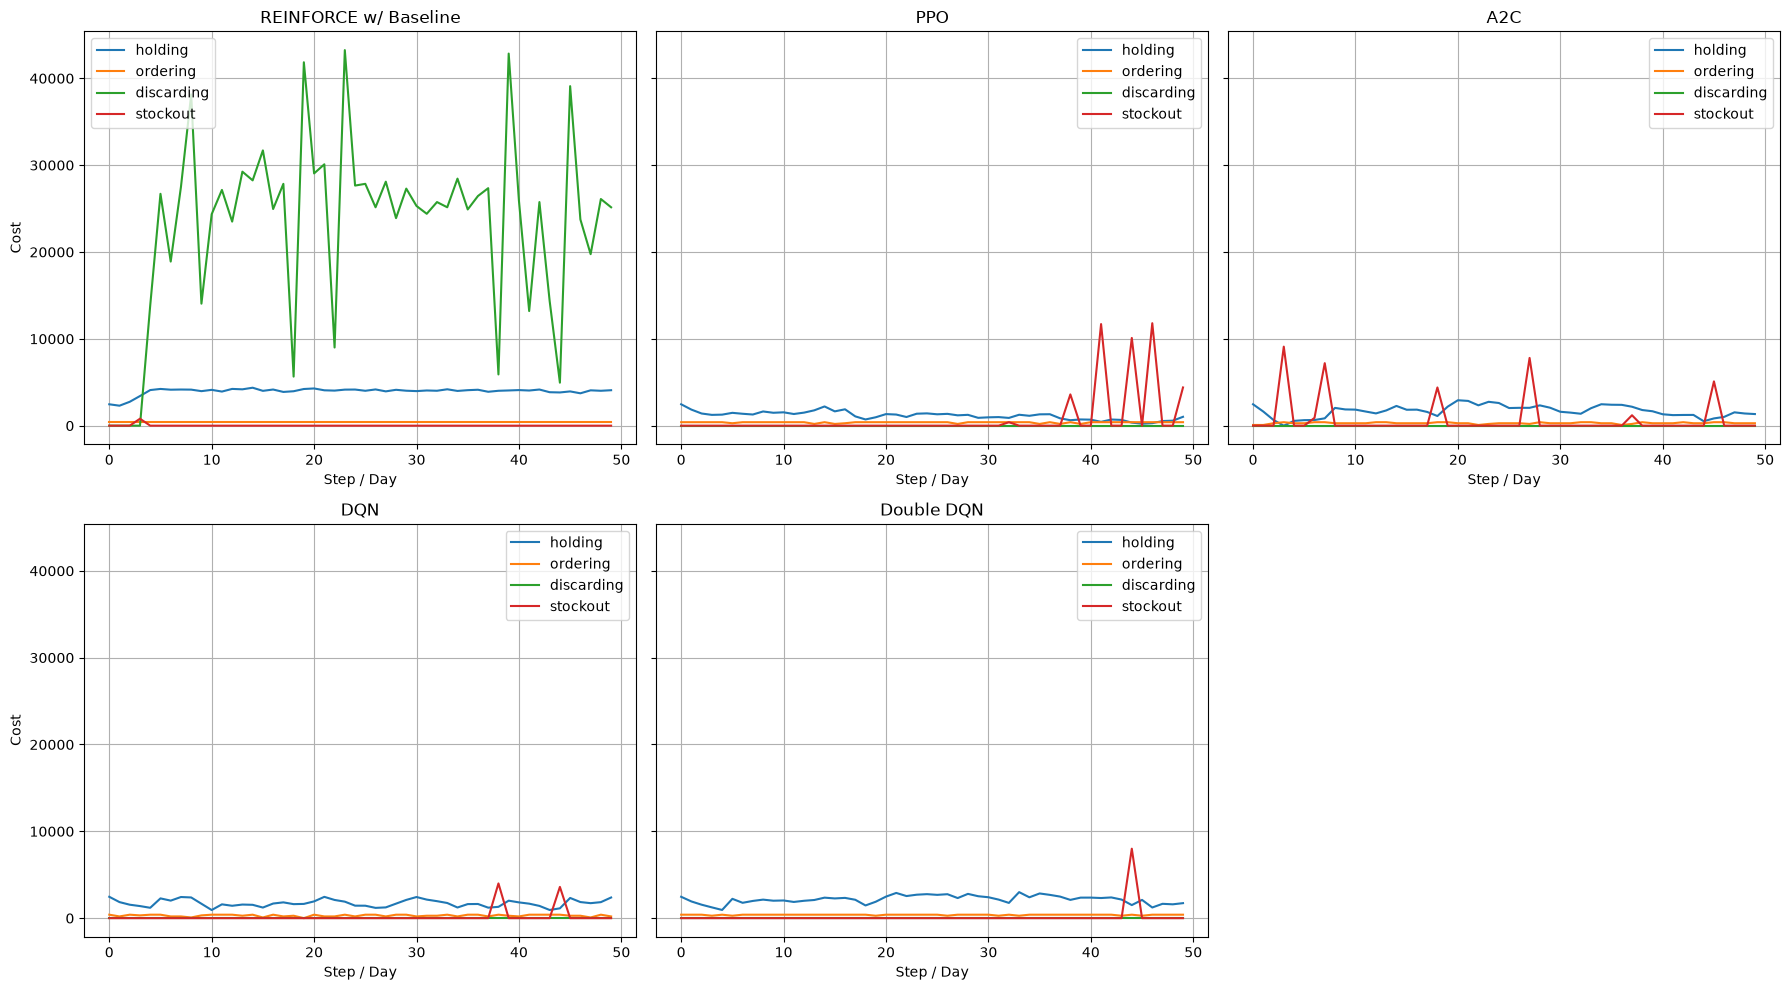

In [ ]:
def run_episode(env, predict_fn):
    records = []
    observation, info = env.reset(seed=SEED)

    while True:
        action = predict_fn(observation)
        observation, reward, terminated, truncated, info = env.step(action)
        records.append({
            "action": action,
            "reward": reward,
            "truncated": truncated,
            "info": info,
            "day": info["day"],
            **info["costs"],
        })
        if terminated or truncated:
            break

    return pd.DataFrame(records)

reinforce_policy = PolicyNetwork().to(DEVICE).eval()
reinforce_policy.load_state_dict(
    torch.load("policies/reinforce_baseline/best_policy_tuned.pth")
)

def predict_reinforce(obs):
    with torch.no_grad():
        obs_tensor = obs_to_tensor(obs)
        action, _ = get_action_and_log_prob(
            reinforce_policy, obs_tensor, deterministic=True
        )
        return action

def make_sb3_predict(model):
    return lambda obs: model.predict(obs, deterministic=True)[0]


def make_dqn_predict(model, shape=(11, 11, 11)):
    def _predict(obs):
        action_scalar, _ = model.predict(obs, deterministic=True)
        return np.unravel_index(action_scalar, shape)

    return _predict


models_config = [
    {
        "name": "REINFORCE w/ Baseline",
        "predict_fn": predict_reinforce,
    },
    {
        "name": "PPO",
        "predict_fn": make_sb3_predict(
            PPO.load("policies/ppo/ppo_inventory_best_searched.zip")
        ),
    },
    {
        "name": "A2C",
        "predict_fn": make_sb3_predict(
            A2C.load("policies/a2c/best_a2c_model.zip")
        ),
    },
    {
        "name": "DQN",
        "predict_fn": make_dqn_predict(
            DQN.load("policies/dqn/dqn_industrial_inventory_tuned.zip")
        ),
    },
    {
        "name": "Double DQN",
        "predict_fn": make_dqn_predict(
            DoubleDQN.load("policies/double_dqn/best_tuned_double_dqn.zip")
        ),
    },
]

cost_cols = ["holding", "ordering", "discarding", "stockout"]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for idx, config in enumerate(models_config):
    ax = axes[idx]
    df = run_episode(env, config["predict_fn"], seed=SEED)

    df[cost_cols].plot(ax=ax, title=config["name"], grid=True)
    ax.set_xlabel("Step / Day")
    ax.set_ylabel("Cost")

# Hide unused 6th subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

NOTE: In below table, the policy file and model artifacts referred are all part of the *.zip files uploaded for each model.

submission_id refers to id of submission in public leaderboard.

In [23]:
technique_tracker = pd.DataFrame(
    [
        {
            "technique": "A2C",
            "submission_id": 3666,
            "best_hyperparameters": {
                "gamma": 0.995,
                "gae_lambda": 0.95,
                "learning_rate": 0.0001040837244840849,
                "ent_coef": 0.00020016991367226302,
                "vf_coef": 0.6335549492874142,
                "max_grad_norm": 0.5128069703757938,
                "n_steps": 256,
                "net_arch": [256,256],
            },
            "local_average_cost": 153_264.25,
            "public_average_cost": 154_022.75,
            "policy_file": "a2c/policy.py",
            "model_artifact": "a2c/best_a2c_model.zip",
        },
        {
            "technique": "Double DQN",
            "submission_id": 3510,
            "best_hyperparameters": {
                'train_freq': 1,
                'target_update_interval': 2000,
                'net_arch': [128, 128],
                'learning_starts': 500,
                'learning_rate': 0.0005,
                'gradient_steps': 1,
                'gamma': 0.99,
                'exploration_fraction': 0.25,
                'exploration_final_eps': 0.1,
                'buffer_size': 50000,
                'batch_size': 128
            },
            "local_average_cost": 104_805.0,
            "public_average_cost": 134_677.50,
            "policy_file": "double_dqn/policy.py",
            "model_artifact": "double_dqn/best_tuned_double_dqn.zip",
        },
        {
            "technique": "DQN",
            "submission_id": 3551,
            "best_hyperparameters": {
                'train_freq': 4, 
                'target_update_interval': 1000, 
                'net_arch': [256, 256], 
                'learning_rate': 0.0007, 
                'gradient_steps': 8, 
                'gamma': 0.99, 
                'exploration_fraction': 0.3, 
                'exploration_final_eps': 0.05, 
                'batch_size': 64
            },
            "local_average_cost": 108_775.0,
            "public_average_cost": 116_214.38,
            "policy_file": "dqn/policy.py",
            "model_artifact": "dqn/dqn_industrial_inventory_tuned.zip",
        },
        {
            "technique": "PPO",
            "submission_id": 3418,
            "best_hyperparameters": {
                "net_arch": [128, 128],
                'vf_coef': 0.75, 
                'n_steps': 512, 
                'n_epochs': 10, 
                'max_grad_norm': 0.7, 
                'learning_rate': 0.00025, 
                'gamma': 0.99, 
                'gae_lambda': 0.9, 
                'ent_coef': 0.01, 
                'clip_range': 0.3, 
                'batch_size': 64
            },
            "local_average_cost": 81_770.0,
            "public_average_cost": 112_479.75,
            "policy_file": "ppo/policy.py",
            "model_artifact": "ppo/ppo_inventory_best_searched.zip",
        },
        {
            "technique": "REINFORCE with Baseline",
            "submission_id": 3621,
            "best_hyperparameters": {
                'actor_lr': 3e-4,
                'critic_lr': 5e-4,
                'gamma': 0.99,
                'entropy_coef': 0.01,
                'hidden_dims': [256, 128],
                'advantage_norm': True,
                'num_episodes': 500,
                'eval_interval': 50,
                'n_eval_episodes': 10
            },
            "local_average_cost": 1_591_876.8,
            "public_average_cost": 1_290_798.88,
            "policy_file": "reinforce_baseline/policy.py",
            "model_artifact": ["reinforce_baseline/best_policy_tuned.pth", "reinforce_baseline/best_value_net_tuned.pth"],
        },
    ]
)
technique_tracker

,technique,submission_id,best_hyperparameters,local_average_cost,public_average_cost,policy_file,model_artifact
0,A2C,3666,"{'gamma': 0.995, 'gae_lambda': 0.95, 'learning...",153264.25,154022.75,a2c/policy.py,a2c/best_a2c_model.zip
1,Double DQN,3510,"{'train_freq': 1, 'target_update_interval': 20...",104805.00,134677.50,double_dqn/policy.py,double_dqn/best_tuned_double_dqn.zip
2,DQN,3551,"{'train_freq': 4, 'target_update_interval': 10...",108775.00,116214.38,dqn/policy.py,dqn/dqn_industrial_inventory_tuned.zip
3,PPO,3418,"{'net_arch': [128, 128], 'vf_coef': 0.75, 'n_s...",81770.00,112479.75,ppo/policy.py,ppo/ppo_inventory_best_searched.zip
4,REINFORCE with Baseline,3621,"{'actor_lr': 0.0003, 'critic_lr': 0.0005, 'gam...",1591876.80,1290798.88,reinforce_baseline/policy.py,"[reinforce_baseline/best_policy_tuned.pth, rei..."
